In [3]:
import yfinance as yf
import numpy as np
import pandas as pd

# Download stock data
df = yf.download('AAPL', start='2015-01-01', end='2025-01-01')

# Use only Close price
data = df[['Close']]
print(data.head())

[*********************100%***********************]  1 of 1 completed

Price           Close
Ticker           AAPL
Date                 
2015-01-02  24.192608
2015-01-05  23.511063
2015-01-06  23.513277
2015-01-07  23.842985
2015-01-08  24.759083


In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [5]:
X = []
y = []

window_size = 60

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

# Reshape for LSTM: [samples, time steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=25))
model.add(Dense(units=1))  # predicted price

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

C:\Users\YASHVIR\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.fit(X, y, epochs=10, batch_size=32)

Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - loss: 0.0124
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0018
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0018
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0017
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0012
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0012
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0011
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0010
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0011
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0010    


In [8]:
predictions = model.predict(X)
predictions = scaler.inverse_transform(predictions)

77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


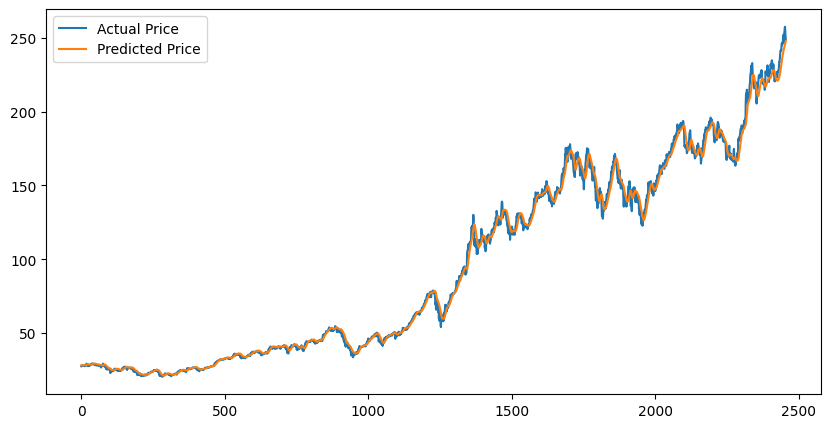

In [9]:
import matplotlib.pyplot as plt

actual = scaler.inverse_transform(y.reshape(-1,1))

plt.figure(figsize=(10,5))
plt.plot(actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.show()

In [10]:
last_60_days = scaled_data[-60:]
X_test = np.array([last_60_days])
X_test = np.reshape(X_test, (1, 60, 1))

next_price = model.predict(X_test)
next_price = scaler.inverse_transform(next_price)

print("Next predicted price:", next_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Next predicted price: 248.12816
